# Dataset Split - Patient-Level Train/Validation

Demonstrates and verifies the patient-level split that `src/preprocess.py`
uses to build `data/processed/manifest.csv`:

1. Discover all raw patients and their sequences
2. Assign binary labels (endometriosis vs healthy)
3. Split **whole patients** into train / validation
4. Prove no patient appears in both sets (no leakage)

**Prerequisite:** raw NIfTI data under `data/raw/UT-EndoMRI/` and the
processed manifest at `data/processed/manifest.csv`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml


def _find_repo_root() -> Path:
    current = Path.cwd().resolve()
    for _ in range(10):
        if (current / "configs" / "config.yaml").exists():
            return current
        current = current.parent
    raise SystemExit(
        "Could not locate configs/config.yaml. Run the notebook from "
        "anywhere inside the repository."
    )

REPO_ROOT = _find_repo_root()
sys.path.insert(0, str(REPO_ROOT))

with open(REPO_ROOT / "configs" / "config.yaml", "r") as fh:
    config = yaml.safe_load(fh)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.titlesize": 11,
    "axes.labelsize": 9,
})

RAW_DIR = REPO_ROOT / config["data"]["raw_dir"]
PROCESSED_DIR = REPO_ROOT / config["data"]["processed_dir"]
sequences = config["preprocessing"]["sequences"]
train_ratio = config["split"]["train_ratio"]
split_seed = config["split"]["seed"]

print("Config loaded.")

Config loaded.


In [2]:
from src.data.dataset import discover_patients

patients = discover_patients(RAW_DIR, sequences)

if not patients:
    raise SystemExit(
        "No raw NIfTI data found under data/raw/. "
        "Place the UT-EndoMRI dataset in data/raw/UT-EndoMRI/."
    )

def origin(pid: str) -> str:
    return "UT-EndoMRI" if pid.startswith(("D1", "D2")) else "healthy_pelvis"

origins = pd.Series([origin(p) for p in patients], index=patients.keys())
print(f"Total patients found: {len(patients)}")
print("Per dataset origin:")
print(origins.value_counts().to_string())

Total patients found: 121
Per dataset origin:
UT-EndoMRI    121


In [3]:
from src.data.dataset import assign_label

patient_ids = sorted(patients.keys())
labels = [assign_label(pid) for pid in patient_ids]
label_counts = pd.Series(labels, index=patient_ids).value_counts()

print("Class distribution (patients):")
print(f"  label 1 (endometriosis): {label_counts.get(1, 0)}")
print(f"  label 0 (healthy)      : {label_counts.get(0, 0)}")
print("\n(label 0 requires the healthy_pelvis dataset, not yet available.)")

Class distribution (patients):
  label 1 (endometriosis): 121
  label 0 (healthy)      : 0

(label 0 requires the healthy_pelvis dataset, not yet available.)


In [4]:
from src.data.dataset import split_patients

splits = split_patients(patient_ids, labels, train_ratio=train_ratio, seed=split_seed)
print(f"Split parameters: train_ratio={train_ratio}, seed={split_seed}\n")

for split_name, ids in splits.items():
    split_labels = [assign_label(pid) for pid in ids]
    pos = sum(split_labels)
    neg = len(split_labels) - pos
    print(f"{split_name}: {len(ids)} patients ({pos} positive, {neg} negative)")

Split parameters: train_ratio=0.8, seed=42

train: 96 patients (96 positive, 0 negative)
validation: 25 patients (25 positive, 0 negative)


In [5]:
train_ids = set(splits["train"])
val_ids = set(splits["validation"])
overlap = train_ids & val_ids

print(f"train patients: {len(train_ids)}")
print(f"val patients  : {len(val_ids)}")
print(f"overlap       : {len(overlap)}")

assert not overlap, f"Leakage: {sorted(overlap)}"
print("PASS: patient sets are disjoint. Each patient belongs to exactly one split.")

from src.data.loader import _assert_disjoint_patients, load_manifest
train_df = load_manifest(PROCESSED_DIR, split="train")
val_df = load_manifest(PROCESSED_DIR, split="validation")
_assert_disjoint_patients(train_df, val_df)
print("PASS: loader guard confirms the on-disk manifest has no patient leakage.")

train patients: 96
val patients  : 25
overlap       : 0
PASS: patient sets are disjoint. Each patient belongs to exactly one split.
PASS: loader guard confirms the on-disk manifest has no patient leakage.


In [6]:
manifest = load_manifest(PROCESSED_DIR)

on_disk_ok = all(pid in splits.get(s, set()) for pid, s in zip(manifest["patient_id"], manifest["split"]))
all_split_ids = set(splits["train"]) | set(splits["validation"])

missing = all_split_ids - set(manifest["patient_id"])
extra = set(manifest["patient_id"]) - all_split_ids

print("Every manifest row resolves to its patient's assigned split:", on_disk_ok)
print("Split-only patients missing from manifest :", sorted(missing) or "none")
print("Manifest patients absent from demo split  :", sorted(extra) or "none")

assert on_disk_ok and not missing and not extra
print("PASS: demonstrated split matches the split baked into the manifest end to end.")

Every manifest row resolves to its patient's assigned split: True
Split-only patients missing from manifest : none
Manifest patients absent from demo split  : none
PASS: demonstrated split matches the split baked into the manifest end to end.


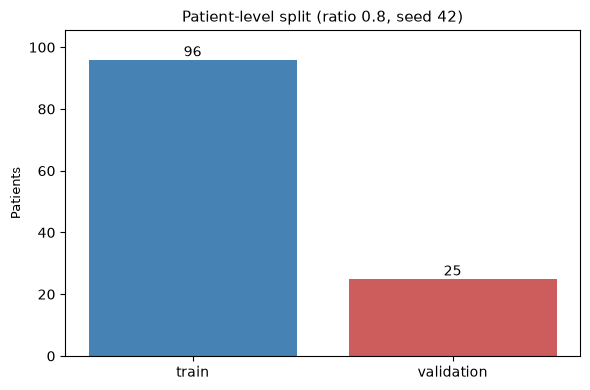

In [7]:
counts = {split_name: len(ids) for split_name, ids in splits.items()}

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(list(counts), list(counts.values()), color=["steelblue", "indianred"])
ax.set_ylabel("Patients")
ax.set_title(f"Patient-level split (ratio {train_ratio}, seed {split_seed})")
for bar, cnt in zip(bars, counts.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(cnt),
            ha="center", va="bottom")
ax.set_ylim(0, max(counts.values()) * 1.1)
plt.tight_layout()
plt.show()

## Summary

- The split operates on **patient IDs** (`split_patients`), so all slices of a
  patient - across every MRI sequence - land in exactly one split.
- The invariant holds both in memory and in the on-disk manifest, and the
  loader's `_assert_disjoint_patients` guard re-checks it at dataset build time.
- With balanced data (label 0 arriving from healthy_pelvis), the same
  `train_test_split` call stratifies on the patient label to keep both classes
  proportionally represented in each split.